# 20260601
- Vero-Elastico 10x10 and 20x20 blocks (no PTFE)

In [ ]:
import numpy as np
from pathlib import Path
import json
import pandas as pd
import pyvista as pv
import matplotlib.pyplot as plt

from phd_helpers.experiments import get_sensor_loc, parse_tekscan, F2P, build_sensor_mesh, project_sensor, project_sensor_new, project_sensor_complex, force_per_frame
from phd_helpers.AbaqusPostprocessing import inp2pv, get_field_path, get_field_df, add_field_to_mesh, get_history_path

In [220]:
cal_path = Path('/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Experimental/LabData/MethodDevelopment/tekscanCalibration/20260601/Movie1.asm')
test_path = Path('/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Experimental/LabData/MethodDevelopment/tekscanCalibration/20260601/Movie3.asm')
fps = 64
time_window = 5 # s (window over which to average frames for each force level)
FRAME_WINDOW = fps * time_window

SENSEL_AREA = 1.6129
PSI2MPA = 0.006894757


## Get calibration frame ranges
- get 5s frame ranges for each force level

In [3]:
# load calibration frames
cal_imgs = parse_tekscan(cal_path, 2)
cal_Rs = np.sum(cal_imgs, axis=(1, 2))

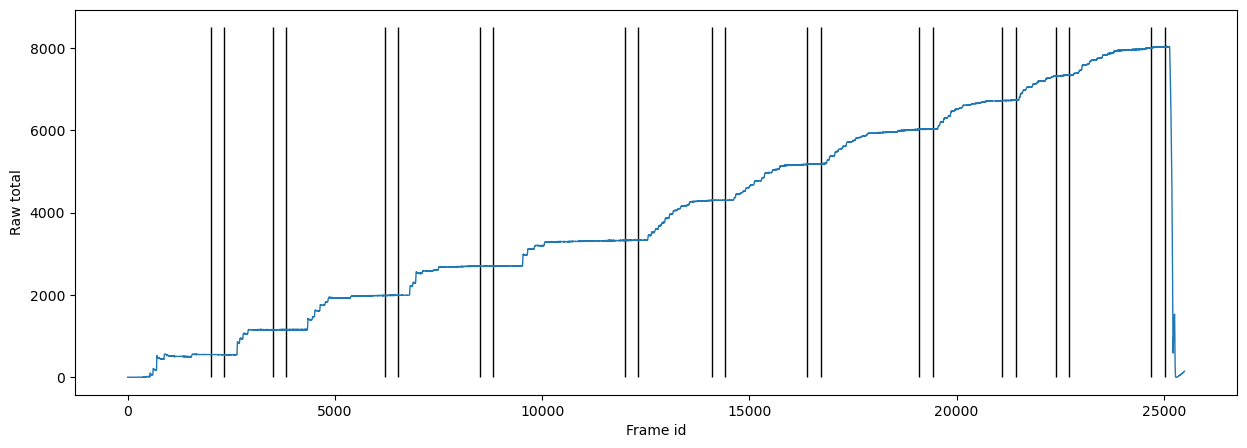

In [4]:
cal_ids = {
    10: 2000,
    25: 3500,
    50: 6200,
    75: 8500,
    100: 12000,
    150: 14100,
    200: 16400,
    250: 19100,
    300: 21100,
    350: 22400,
    400: 24700
}

nrows, ncols = 1, 1
fig, ax = plt.subplots(nrows, ncols, figsize=(15*ncols, 5*nrows))

for val in cal_ids.values():
    ax.vlines([val, val+FRAME_WINDOW], ymin=0, ymax=8500, color='black', linewidth=1)

ax.plot(np.arange(len(cal_Rs)), cal_Rs, linewidth=1)
ax.set_xlabel('Frame id')
ax.set_ylabel('Raw total')
plt.show()

## Get test frame ranges
- get 5s frame ranges for each force level

In [5]:
# load calibration frames
test_imgs = parse_tekscan(test_path, 2)
test_Rs = np.sum(test_imgs, axis=(1, 2))

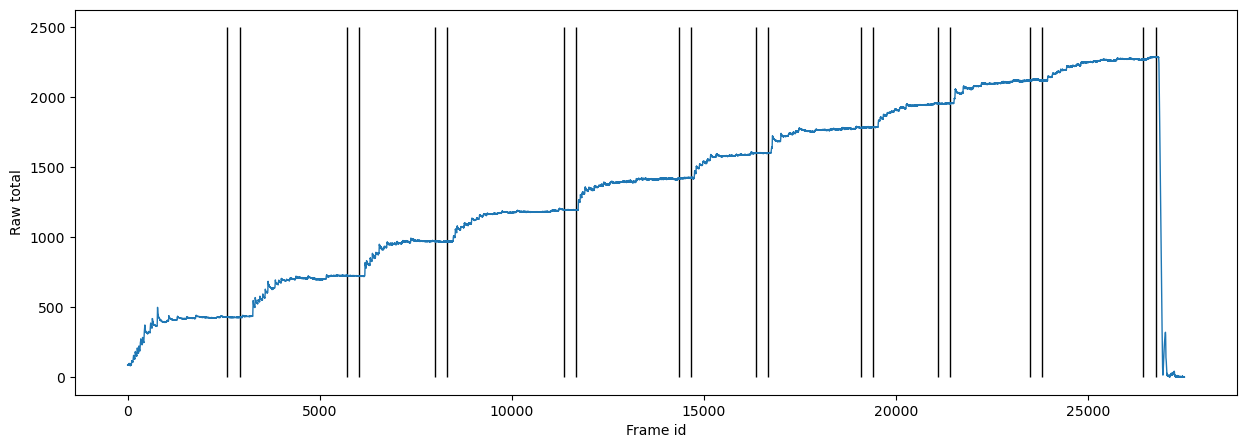

In [6]:
test_ids = {
    10: 2600,
    20: 5700,
    30: 8000,
    40: 11350,
    50: 14350,
    60: 16350,
    70: 19100,
    80: 21100,
    90: 23500,
    100: 26450
}

nrows, ncols = 1, 1
fig, ax = plt.subplots(nrows, ncols, figsize=(15*ncols, 5*nrows))

for val in test_ids.values():
    ax.vlines([val, val+FRAME_WINDOW], ymin=0, ymax=2500, color='black', linewidth=1)

ax.plot(np.arange(len(test_Rs)), test_Rs, linewidth=1)
ax.set_xlabel('Frame id')
ax.set_ylabel('Raw total')
plt.show()

## Compute frame averages
- Take the average of the frame windows for each force level

In [7]:
def avg_frames(frames, frame_ids_dict):
    return {key: np.mean(frames[val:val+FRAME_WINDOW], axis=0) for key, val in frame_ids_dict.items()}

In [8]:
cal_frames = avg_frames(cal_imgs, cal_ids)
test_frames = avg_frames(test_imgs, test_ids)

In [236]:
from scipy.optimize import minimize_scalar
def compute_power_law_coeffs(cal_frames, sensel_area=1.6129, return_fit_points=False, mask=1):
    """
    P = a r^b

    P is pressure, r is sensel raw 8-bit value.
    Fit is done at patch level:
        p_i ≈ a * mean(x_i ** b)
    """

    patches = [x for x in cal_frames.values()]
    Fs = np.array([x for x in cal_frames.keys()], dtype=float)

    xs = [
        np.asarray(p, dtype=float)[np.asarray(p, dtype=float) >= mask]
        for p in patches
    ]

    n = np.array([len(x) for x in xs], dtype=float)
    area = n * sensel_area
    p = Fs / area

    def S(b):
        return np.array([np.mean(x ** b) for x in xs])

    def a_of_b(b):
        s = S(b)
        w = area ** 2
        return np.dot(w * p, s) / np.dot(w * s, s)

    def J(b):
        s = S(b)
        a = a_of_b(b)
        return np.sum((area * (a * s - p)) ** 2)

    res = minimize_scalar(J, bounds=(0, 3), method="bounded")

    b = res.x
    a = a_of_b(b)

    if not return_fit_points:
        return a, b

    s = S(b)
    p_fit = a * s

    # Effective raw value for each calibration patch
    r_eff = s ** (1 / b)

    fit_points = {
        "raw_eff": r_eff,
        "pressure_actual": p,
        "pressure_fit": p_fit,
        "force": Fs,
        "area": area,
        "n_sensels": n,
    }

    return a, b, fit_points

In [18]:
a, b = compute_power_law_coeffs(cal_frames)
test_frames_mpa = {f: a*x**b for f, x in test_frames.items()}

In [65]:
for F, frame in test_frames_mpa.items():
    print(f'Instron force: {F}')
    print(f'Tekscan force: {force_per_frame(frame.reshape(1, 11, 11))[0]:.2f}\n')

Instron force: 10
Tekscan force: 10.68

Instron force: 20
Tekscan force: 22.11

Instron force: 30
Tekscan force: 33.12

Instron force: 40
Tekscan force: 44.07

Instron force: 50
Tekscan force: 55.37

Instron force: 60
Tekscan force: 64.38

Instron force: 70
Tekscan force: 74.58

Instron force: 80
Tekscan force: 84.34

Instron force: 90
Tekscan force: 94.60

Instron force: 100
Tekscan force: 104.62



In [71]:
test_frames_mpa[50].max()

np.float64(6.723274723968404)

In [72]:
test_frames[50].max()

np.float64(179.003125)

In [83]:
cal_frames[400][cal_frames[400]>3].mean()

np.float64(104.09460227272727)

# Thoughts
- total force is really good
    - Could just use this and fit fea to match average pressure, contact area, and contact location?
- peak pressure looks really high
    - Don't use this for fea, just say that peak pressure was found to be very sensitive to calibration so less trustworthy?

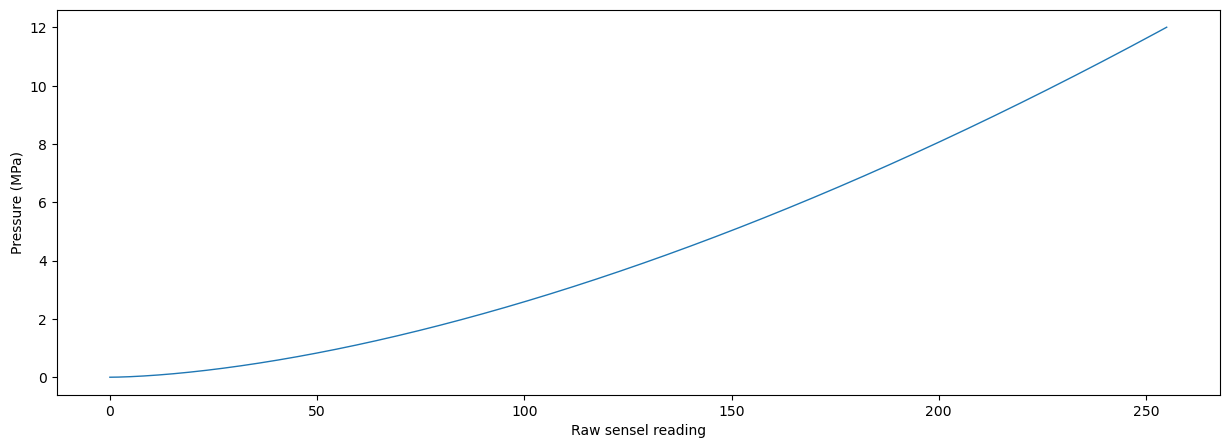

In [59]:
nrows, ncols = 1, 1
fig, ax = plt.subplots(nrows, ncols, figsize=(15*ncols, 5*nrows))

xs = np.linspace(0, 255, 1000)
ys = a*xs**b

ax.plot(xs, ys, linewidth=1)


ax.set_xlabel('Raw sensel reading')
ax.set_ylabel('Pressure (MPa)')
plt.show()

# 20260605
- Vero-Elastico-PTFE 10x10 20x20 blocks
---
- look at tekscan's calibration based on 25N and 500N frames
    - lower max pressure than without PTFE, but still much higher than FEA
- try calibrating based on actual area
- try calibrating based on every force step frame
---
Need to figure out calibration force levels first cos there seems to be an extra level in there
- looks like 125 N and 400 N were included

In [221]:
cal_file = Path('../../../LabData/MethodDevelopment/tekscanCalibration/20260605/VE10PTFE-25-500N.cal')
cal_path = Path('../../../LabData/MethodDevelopment/tekscanCalibration/20260605/cal-10-700N.asm')
test_path = Path('../../../LabData/MethodDevelopment/tekscanCalibration/20260605/test-10-150N.asm')

fps = 64
time_window = 3 # s (window over which to average frames for each force level)
FRAME_WINDOW = fps * time_window

In [ ]:
def extract_tekcsan_coeffs(cal_file):
    """get the scale (a) and exponent (b) from a tekscan calibration file (PSI)"""
    a, b = 1, 1
    with open(cal_file, 'r') as f:
        for line in f:
            if 'SCALE_FACTOR' in line:
                a = float(line.split(' ')[1].strip())
            if 'EXPONENT' in line:
                b = float(line.split(' ')[1].strip())
    return a, b



## Figure out calibration force levels for cal-10-700N.asm
- looks like 125 and 400 N were included

In [112]:
cal_frames = parse_tekscan(cal_path, 2)
cal_Rs = np.sum(cal_frames, axis=(1, 2))

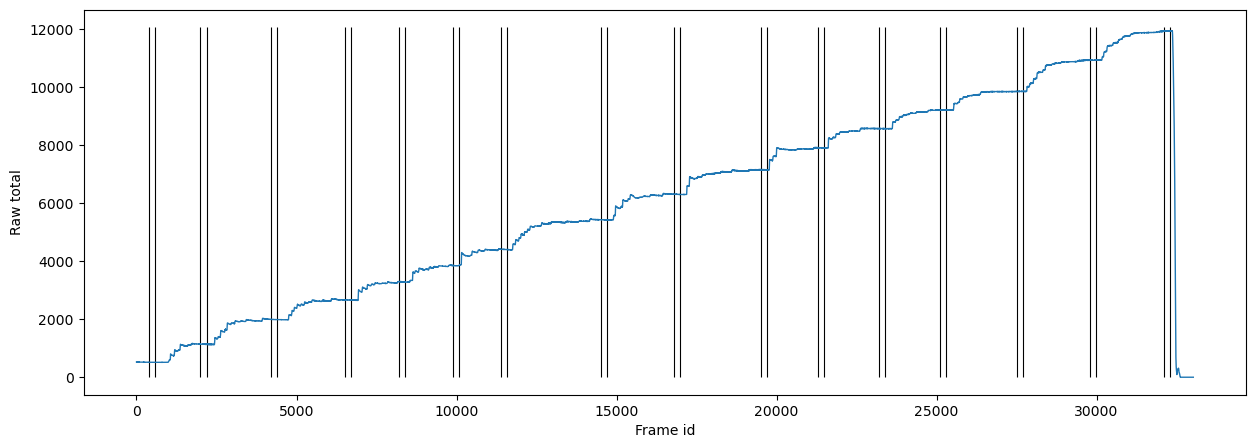

In [187]:
cal_ids = {
    10: 400,
    25: 2000,
    50: 4200,
    75: 6500,
    100: 8200,
    125: 9900,
    150: 11400,
    200: 14500,
    250: 16800,
    300: 19500,
    350: 21300,
    400: 23200,
    450: 25100,
    500: 27500,
    600: 29800,
    700: 32100
}

nrows, ncols = 1, 1
fig, ax = plt.subplots(nrows, ncols, figsize=(15*ncols, 5*nrows))

for val in cal_ids.values():
    ax.vlines([val, val+FRAME_WINDOW], ymin=0, ymax=cal_Rs.max()+(0.01*cal_Rs.max()), color='black', linewidth=0.8)

ax.plot(np.arange(len(cal_Rs)), cal_Rs, linewidth=1)
ax.set_xlabel('Frame id')
ax.set_ylabel('Raw total')
plt.show()

In [ ]:
cal_data_raw = avg_frames(cal_frames, cal_ids)
a, b = extract_tekcsan_coeffs(cal_file)
cal_data_mpa = {f: (a*x**b) * PSI2MPA for f, x in cal_data_raw.items()}

In [189]:
for F, frame in cal_data_mpa.items():
    print(f'Instron force: {F}')
    print(f'Tekscan force: {force_per_frame(frame.reshape(1, 11, 11))[0]:.2f}\n')

Instron force: 10
Tekscan force: 8.61

Instron force: 25
Tekscan force: 25.07

Instron force: 50
Tekscan force: 54.36

Instron force: 75
Tekscan force: 81.44

Instron force: 100
Tekscan force: 109.36

Instron force: 125
Tekscan force: 135.82

Instron force: 150
Tekscan force: 163.83

Instron force: 200
Tekscan force: 218.99

Instron force: 250
Tekscan force: 269.82

Instron force: 300
Tekscan force: 321.50

Instron force: 350
Tekscan force: 369.75

Instron force: 400
Tekscan force: 413.00

Instron force: 450
Tekscan force: 455.95

Instron force: 500
Tekscan force: 500.38

Instron force: 600
Tekscan force: 578.22

Instron force: 700
Tekscan force: 653.67



## Check 25 - 500 N calibration curve
- from VE10PTFE-25-500N.cal
- Slightly more sensible max value than without ptfe

a: 0.466561
b: 1.45977


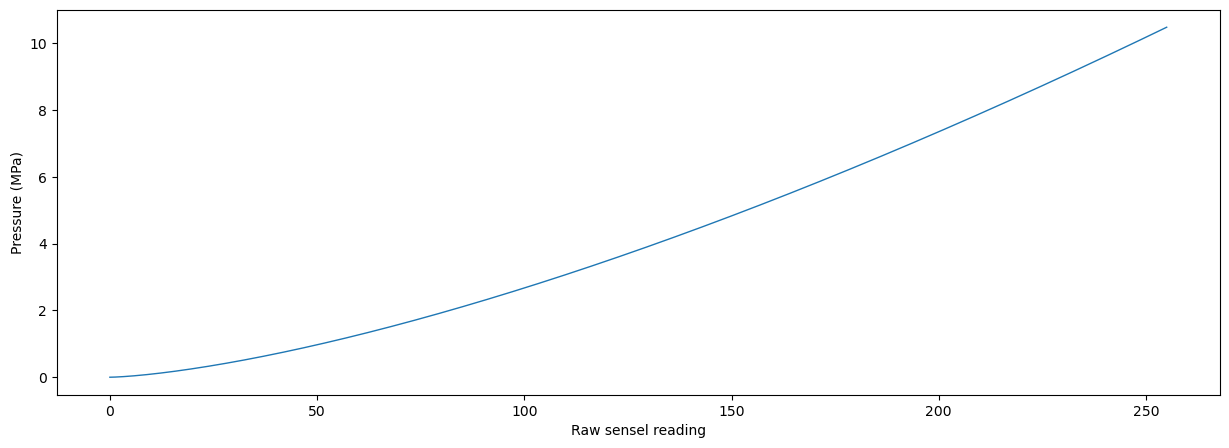

In [ ]:
nrows, ncols = 1, 1
fig, ax = plt.subplots(nrows, ncols, figsize=(15*ncols, 5*nrows))

xs = np.linspace(0, 255, 1000)
a, b = extract_tekcsan_coeffs(cal_file)
ys = (a*xs**b) * PSI2MPA

ax.plot(xs, ys, linewidth=1)

print(f'a: {a}\nb: {b}')

ax.set_xlabel('Raw sensel reading')
ax.set_ylabel('Pressure (MPa)')
plt.show()

## Calibrate using all force level frames

#### Using tekscans method

a: 0.001083
b: 1.679412


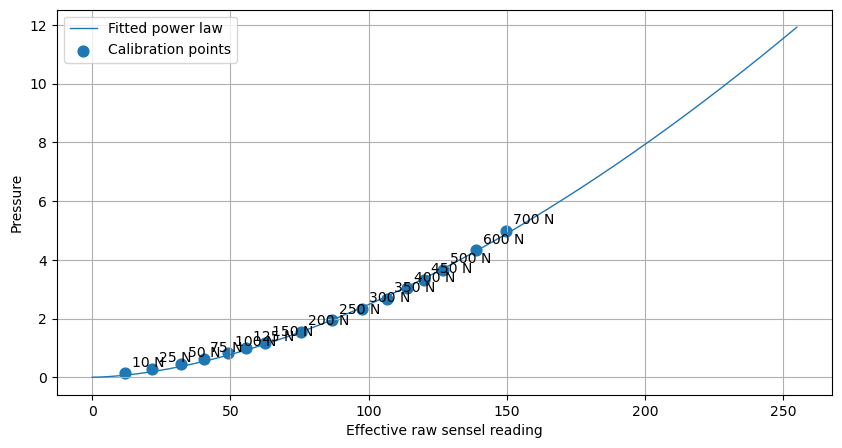

In [216]:
a_allF, b_allF, fit_points = compute_power_law_coeffs(
    cal_data_raw,
    return_fit_points=True
)

fig, ax = plt.subplots(figsize=(10, 5))

# Fitted curve
raw = np.linspace(0, 255, 1000)
pressure = a_allF * raw ** b_allF

ax.plot(raw, pressure, linewidth=1, label="Fitted power law")

# Points used for fitting, one per calibration load
ax.scatter(
    fit_points["raw_eff"],
    fit_points["pressure_actual"],
    s=60,
    label="Calibration points"
)

for F, x, y in zip(
    fit_points["force"],
    fit_points["raw_eff"],
    fit_points["pressure_actual"]
):
    ax.annotate(f"{F:g} N", (x, y), xytext=(5, 5), textcoords="offset points")

print(f"a: {a_allF:.6f}")
print(f"b: {b_allF:.6f}")

ax.set_xlabel("Effective raw sensel reading")
ax.set_ylabel("Pressure")
ax.legend()
ax.grid(True)
plt.show()

#### Using tekscans method - with mask = 5
- mask makes no difference

a: 0.001084
b: 1.679274


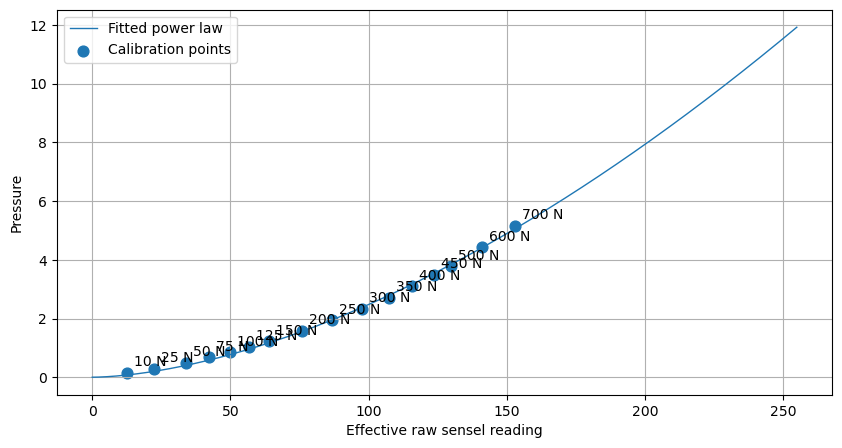

In [217]:
mask_raw = 5 # ≤ masked
cal_data_raw_masked = {key: np.where(val <= mask_raw, 0, val) for key, val in cal_data_raw.items()}

a_allF, b_allF, fit_points = compute_power_law_coeffs(
    cal_data_raw_masked,
    return_fit_points=True
)

fig, ax = plt.subplots(figsize=(10, 5))

# Fitted curve
raw = np.linspace(0, 255, 1000)
pressure = a_allF * raw ** b_allF

ax.plot(raw, pressure, linewidth=1, label="Fitted power law")

# Points used for fitting, one per calibration load
ax.scatter(
    fit_points["raw_eff"],
    fit_points["pressure_actual"],
    s=60,
    label="Calibration points"
)

for F, x, y in zip(
    fit_points["force"],
    fit_points["raw_eff"],
    fit_points["pressure_actual"]
):
    ax.annotate(f"{F:g} N", (x, y), xytext=(5, 5), textcoords="offset points")

print(f"a: {a_allF:.6f}")
print(f"b: {b_allF:.6f}")

ax.set_xlabel("Effective raw sensel reading")
ax.set_ylabel("Pressure")
ax.legend()
ax.grid(True)
plt.show()

#### Based on true area (10x10 mm) of calibration block

100 mm^2


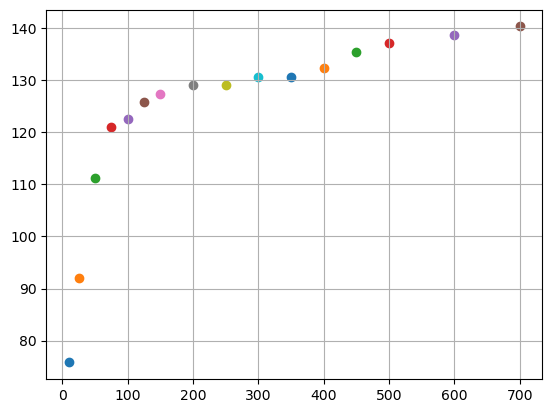

In [226]:
fig, ax = plt.subplots()
for key, val in cal_data_raw.items():
    ax.scatter(key, np.sum(val>0)*SENSEL_AREA)

ax.grid()
print(10*10, 'mm^2')
plt.show()

In [ ]:
# 10x10 block should cover 8x8 area of sensels
SENSEL_AREA * 8 * 8

103.2256

In [224]:
# getting around 18-19 extra active sensels
(130 - 100) / SENSEL_AREA

18.6000372000744

#### What if you only fit the curve to the 64 highest raw values?
- Makes the curve even steeper...

a: 0.000964
b: 1.707977


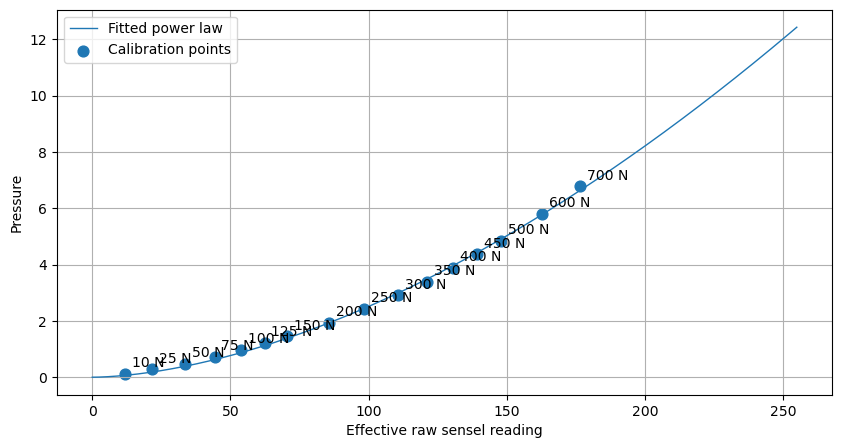

In [238]:
cal_data_raw_64 = {key: np.sort(val.ravel())[::-1][:64] for key, val in cal_data_raw.items()}

a_allF, b_allF, fit_points = compute_power_law_coeffs(
    cal_data_raw_64,
    return_fit_points=True
)

fig, ax = plt.subplots(figsize=(10, 5))

# Fitted curve
raw = np.linspace(0, 255, 1000)
pressure = a_allF * raw ** b_allF

ax.plot(raw, pressure, linewidth=1, label="Fitted power law")

# Points used for fitting, one per calibration load
ax.scatter(
    fit_points["raw_eff"],
    fit_points["pressure_actual"],
    s=60,
    label="Calibration points"
)

for F, x, y in zip(
    fit_points["force"],
    fit_points["raw_eff"],
    fit_points["pressure_actual"]
):
    ax.annotate(f"{F:g} N", (x, y), xytext=(5, 5), textcoords="offset points")

print(f"a: {a_allF:.6f}")
print(f"b: {b_allF:.6f}")

ax.set_xlabel("Effective raw sensel reading")
ax.set_ylabel("Pressure")
ax.legend()
ax.grid(True)
plt.show()